In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix
import random


In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms
from torchvision.transforms import v2


In [3]:
def seed_everything(seed=42):
    """
    Sets the random seed for reproducibility across multiple libraries and devices.
    """
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False # set to False for deterministic behavior
    # torch.backends.cudnn.enabled = False # can be set to False if needed
    print(f"Random seed set to {seed}")

# Usage:
seed_everything(0)

Random seed set to 0


In [4]:
# Set the global random seed for reproducibility
np.random.seed(0)


# set device, which gpu to use.
device ='cpu'
if torch.cuda.is_available():
    device='cuda:0'
print(device)

cuda:0


In [5]:
# Check the specifications of your machine/what resources you have been allocated through Colab.
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Thu Jul  2 03:48:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')
root_folder = '/content/drive/MyDrive/OIST-mini-course'
!ls $root_folder

Mounted at /content/drive
cls_train.pkl
cls_val.pkl
code001_part-A_setup.ipynb
code001_part-B_setup.ipynb
code001_setup_readme.docx
code001_setup_readme.pdf
code002_data_prep_NN.ipynb
code003_LogReg.ipynb
code004_DNN_scratch.ipynb
code005_part-A_detection_dataPrep.ipynb
code005_part-B_pollen_detection_model_design.ipynb
code005_part-C_pollen_detection_training.ipynb
code006_part-A_DNN_finetune.ipynb
code006_part-B_pollen_detection_finetune.ipynb
dataset_for_classification
dataset_for_classification.zip
dataset_for_detection
dataset_for_detection.zip
det_trainval_splits.pkl
meta_detection.pkl
slides
test-image.jpg
test-image-sharpened.jpg


# config hyperparameters

In [7]:
batch_size = 32
epoch_num = 50
lr = 0.0005 # base learning rate
weight_decay = 0.0005


exp_dir = './exp' # experiment directory, used for reading the init model
prefix = 'vanilla'
postfix = 'v1'

project_name = prefix + '_' + postfix   # we save all the checkpoints in this directory
print(project_name)

save_dir = os.path.join(exp_dir, project_name)

log_filename = os.path.join(save_dir, 'train_%f.log' % weight_decay)
print(save_dir)

if not os.path.exists(save_dir): os.makedirs(save_dir)


vanilla_v1
./exp/vanilla_v1


# make PyTorch-friendly dataloaders for train and validation sets

In [8]:
filename_train = os.path.join(root_folder, 'cls_train.pkl')
filename_val = os.path.join(root_folder, 'cls_val.pkl')

with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

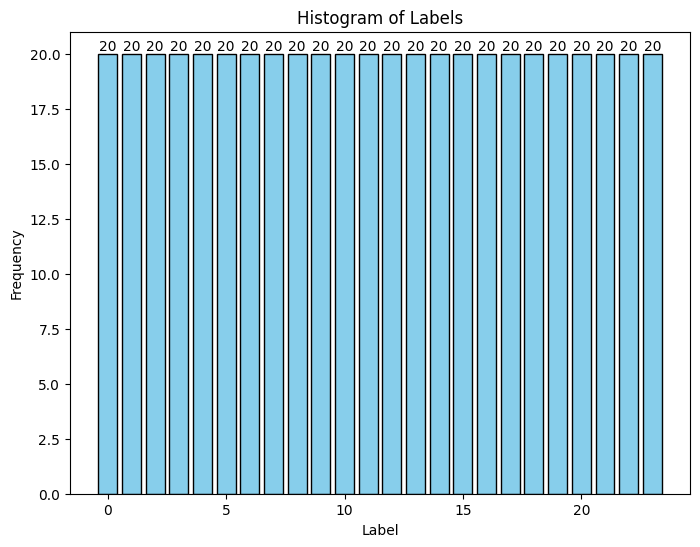

In [9]:
unique_labels, counts = np.unique(train_labellist, return_counts=True)


plt.figure(figsize=(8, 6))
plt.bar(unique_labels, counts, color='skyblue', edgecolor='black')

# Add axis labels and title
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('Histogram of Labels')

# Add frequency labels on top of the bars
for i in range(len(counts)):
    plt.text(unique_labels[i], counts[i], str(counts[i]), ha='center', va='bottom')

plt.show()

## a helper to read data


In [10]:
class pollenDataset(Dataset):
    def __init__(self, imgpathList, labelList, transform=None, is_trainset=False):
        self.imgpathList = imgpathList
        self.labelList = labelList
        self.transform=transform
        self.current_set_len = len(labelList)
        self.is_trainset = is_trainset

    def __len__(self):
        return self.current_set_len

    def __getitem__(self, idx):
        cur_img = self.imgpathList[idx]
        cur_label = self.labelList[idx]
        cur_img = skimage.io.imread(cur_img).astype(np.float32) / 255.0

        cur_img = cur_img[cur_img.shape[0]//2-64:cur_img.shape[0]//2+64,
                          cur_img.shape[1]//2-64:cur_img.shape[1]//2+64,
                          :] # suppose the new feature is a 100x100 square region in image center

        # cur_img = Image.fromarray(cur_img)
        # cur_img = Image.open(cur_img)
        # print(cur_img.max(),cur_img.min())

        if self.is_trainset:
            if np.random.rand()>0.5:
                cur_img[:,:,0] = np.fliplr(cur_img[:,:,0])
                cur_img[:,:,1] = np.fliplr(cur_img[:,:,1])
                cur_img[:,:,2] = np.fliplr(cur_img[:,:,2])
            if np.random.rand()>0.5:
                cur_img[:,:,0] = np.flipud(cur_img[:,:,0])
                cur_img[:,:,1] = np.flipud(cur_img[:,:,1])
                cur_img[:,:,2] = np.flipud(cur_img[:,:,2])


        if self.transform is not None:
            cur_img = self.transform(cur_img)
            # print('       ', cur_img.max(),cur_img.min())
        return cur_img, cur_label

In [11]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

data_train_transform = transforms.Compose([
    # v2.RandomResize(min_size=240, max_size=400),
    # transforms.RandomCrop(224),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


data_val_transform = transforms.Compose([
    # transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [12]:
trainset = pollenDataset(imgpathList=trainset_info['train_imgpathlist'],
                         labelList=train_labellist,
                         transform=data_train_transform,
                         is_trainset=True
                        )

valset = pollenDataset(imgpathList=valset_info['val_imgpathlist'],
                       labelList=val_labellist,
                       transform=data_val_transform,
                       is_trainset=False
                      )

In [13]:
print(len(trainset), len(valset))

480 120


In [14]:
dataloader_trainset = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
dataloader_valset = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)

print(len(dataloader_trainset), len(dataloader_valset))

15 4


In [15]:
i = 0
for sample in dataloader_valset:
    i+=1
    if i%10==0:
        print(i, len(dataloader_valset))
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)

In [16]:
cur_Img.shape, cur_Label.shape

(torch.Size([24, 3, 128, 128]), torch.Size([24]))

# Set a Convolutional Neural Network (CNN)

In [17]:
class ModelArchitecture(nn.Module):
    def __init__(self, num_classes=20, pretrained=False):
        super().__init__()
        if pretrained:
            self.backbone = models.resnet18(weights='IMAGENET1K_V1') # or pretrained=True
        else:
            self.backbone = models.resnet18() # or pretrained=True
        self.backbone.fc = nn.Identity() # remove classification head
        feat_dim = 512
        self.dropout = nn.Dropout(0.5)
        self.cls_head = nn.Linear(feat_dim, num_classes)
    def forward(self, x):
        feat = self.backbone(x)
        feat = self.dropout(feat)
        logits = self.cls_head(feat)
        return logits

In [18]:
pretrained = True
myModel = ModelArchitecture(num_classes=numClasses, pretrained=pretrained).to(device)
myModel.train()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


ModelArchitecture(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

In [19]:
output = myModel(cur_Img)

In [20]:
loss_fn = nn.CrossEntropyLoss()
# optimizer = optim.AdamW(myModel.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=weight_decay)

# optimizer = optim.AdamW(myModel.parameters(), lr=lr, betas=(0.9, 0.999), weight_decay=weight_decay)
optimizer = optim.AdamW([
    {'params': myModel.backbone.parameters(), 'lr': 0.00001, 'weight_decay':weight_decay},
    {'params': myModel.cls_head.parameters(), 'lr': 0.0001, 'weight_decay':weight_decay}])

scheduler = lr_scheduler.CosineAnnealingLR(optimizer, epoch_num, eta_min=0)

# Train this CNN

In [21]:
def append_to_log(log_filename, content_string):
    fn = open(log_filename,'a')
    fn.write('{}\n'.format(content_string))
    fn.close()


In [22]:
best_epoch_id = -1
best_loss = torch.inf
list_val_loss = np.zeros(epoch_num)
list_train_loss = np.zeros(epoch_num)


bestmodel_filename = os.path.join(save_dir, 'bestmodel_%f.params' % weight_decay)


fn = open(log_filename,'w')
fn.write('{}\n'.format(project_name))
fn.close()

for epoch in range(epoch_num):
    # training
    cur_string = 'epoch %d/%d...' % (epoch, epoch_num)
    print(cur_string)
    append_to_log(log_filename, cur_string)

    myModel.train();
    cur_loss = 0
    i=0
    for sample in dataloader_trainset:
        i+=1
        if i%20==0:
            cur_string = '\t%d / %d' %(i, len(dataloader_trainset))
            print(cur_string)
            append_to_log(log_filename, cur_string)

        cur_Img, cur_Label = sample
        cur_Img = cur_Img.to(device)
        cur_Label = cur_Label.to(device)
        optimizer.zero_grad()
        output = myModel(cur_Img)
        loss = loss_fn(output, cur_Label)
        cur_loss += loss.data

        # backward pass
        loss.backward()

        # update weights
        optimizer.step()

    scheduler.step()
    cur_loss = cur_loss / len(dataloader_trainset)
    list_train_loss[epoch] = cur_loss
    cur_string = '\ttrain CE: %.4f' % (cur_loss)
    print(cur_string)
    append_to_log(log_filename, cur_string)

    # evaluation
    cur_string = '   evaluation...'
    print(cur_string)
    append_to_log(log_filename, cur_string)
    myModel.eval();
    cur_loss = 0
    for sample in dataloader_valset:
        cur_Img, cur_Label = sample
        cur_Img = cur_Img.to(device)
        cur_Label = cur_Label.to(device)
        output = myModel(cur_Img)
        tmp = loss_fn(output, cur_Label)
        cur_loss += tmp.data
    cur_loss = cur_loss/len(dataloader_valset)
    list_val_loss[epoch] = cur_loss
    if cur_loss<best_loss:
        best_epoch_id = epoch
        best_loss = cur_loss
        torch.save(myModel.state_dict(), bestmodel_filename)
    cur_string = '\tcurrent CE: %.4f, best CE: %.4f at epoch-%d' % (cur_loss, best_loss, best_epoch_id)
    print(cur_string)
    append_to_log(log_filename, cur_string)

epoch 0/50...
	train CE: 3.6782
   evaluation...
	current CE: 3.3274, best CE: 3.3274 at epoch-0
epoch 1/50...
	train CE: 3.3877
   evaluation...
	current CE: 3.1790, best CE: 3.1790 at epoch-1
epoch 2/50...
	train CE: 3.1168
   evaluation...
	current CE: 2.9562, best CE: 2.9562 at epoch-2
epoch 3/50...
	train CE: 2.9672
   evaluation...
	current CE: 2.7481, best CE: 2.7481 at epoch-3
epoch 4/50...
	train CE: 2.7900
   evaluation...
	current CE: 2.5800, best CE: 2.5800 at epoch-4
epoch 5/50...
	train CE: 2.6157
   evaluation...
	current CE: 2.4374, best CE: 2.4374 at epoch-5
epoch 6/50...
	train CE: 2.4328
   evaluation...
	current CE: 2.3229, best CE: 2.3229 at epoch-6
epoch 7/50...
	train CE: 2.3819
   evaluation...
	current CE: 2.2188, best CE: 2.2188 at epoch-7
epoch 8/50...
	train CE: 2.2365
   evaluation...
	current CE: 2.1150, best CE: 2.1150 at epoch-8
epoch 9/50...
	train CE: 2.0974
   evaluation...
	current CE: 2.0212, best CE: 2.0212 at epoch-9
epoch 10/50...
	train CE: 1.94

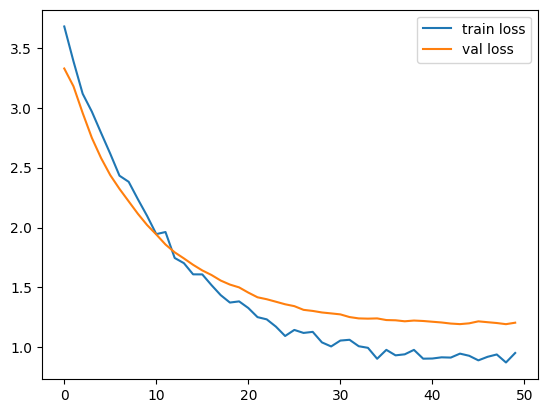

In [23]:
plt.plot(list_train_loss, label='train loss')
plt.plot(list_val_loss, label='val loss')
plt.legend()

# Use the last checkpoint

In [24]:
myModel.eval();
predList = []
for sample in dataloader_valset:
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)
    logits = myModel(cur_Img).detach()
    output = F.softmax(logits, dim=0)
    output = output.cpu().numpy()
    output = np.argmax(output, 1)
    predList = np.concatenate((predList, output))

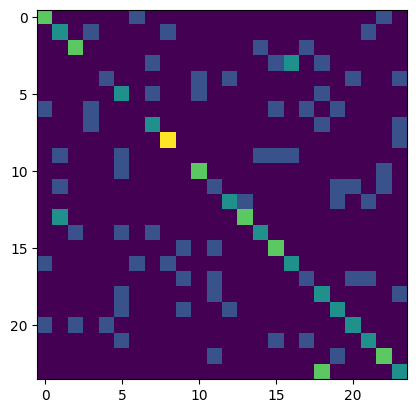

In [25]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [26]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.392


# Use the selected checkpoint

In [27]:
bestmodel_filename

'./exp/vanilla_v1/bestmodel_0.000500.params'

In [28]:
myModel = ModelArchitecture(num_classes=numClasses).to(device)
myModel.load_state_dict(torch.load(bestmodel_filename))

<All keys matched successfully>

In [29]:
myModel.eval();
predList = []
for sample in dataloader_valset:
    cur_Img, cur_Label = sample
    cur_Img = cur_Img.to(device)
    cur_Label = cur_Label.to(device)
    logits = myModel(cur_Img).detach()
    output = F.softmax(logits, dim=0)
    output = output.cpu().numpy()
    output = np.argmax(output, 1)
    predList = np.concatenate((predList, output))

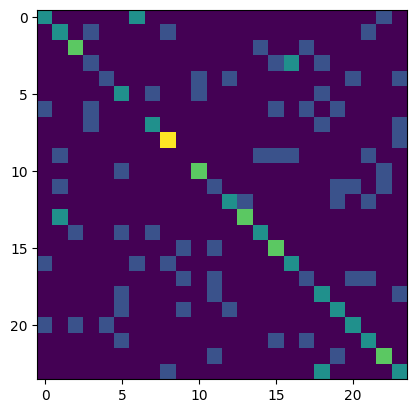

In [30]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')

plt.imshow(conf)

In [31]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.392
